In [14]:
# Импорт базовых библиотек для работы с данными и визуализации
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт инструментов машинного обучения для подготовки данных
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Подключение Google Drive для доступа к файлам датасета
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Чтение данных
train_df = pd.read_csv('/content/drive/MyDrive/SF/для итогового проекта по нейросетям/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/SF/для итогового проекта по нейросетям/test.csv')

# Посмотрим на первые 5 строк
display(train_df.head())


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


In [8]:
# Общая информация: типы данных и пропуски
print(train_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  

In [9]:
# Статистика: средние значения, мин/макс
display(train_df.describe())


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,54.426085,0.677447,3.170247,131.340485,249.592420,0.150757,1.020148,149.592069,0.333502,1.051391,1.596033,0.681303,4.711378,0.444185
std,173205.225094,9.086041,0.467454,0.949618,17.842450,51.699976,0.357812,0.994204,23.072593,0.471464,1.144288,0.629821,0.950669,1.934766,0.496875
min,0.000000,26.061695,0.000000,-0.538498,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,149999.750000,48.078493,0.000000,3.000000,119.924094,216.475964,0.000000,0.000000,135.704237,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,299999.500000,55.133425,1.000000,3.000000,129.727941,244.233699,0.000000,2.000000,153.224828,0.000000,0.811101,2.000000,0.000000,3.000000,0.000000
75%,449999.250000,60.663775,1.000000,4.000000,139.915216,274.345453,0.000000,2.000000,165.165497,1.000000,1.674081,2.000000,1.000000,7.000000,1.000000
max,599999.000000,79.591647,1.000000,4.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


In [10]:
# Проверка на пропуски (в цифрах)
print(train_df.isnull().sum())

ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64


###Предобработка данных

In [4]:
from sklearn.preprocessing import LabelEncoder

# 1. Оптимизация памяти: переводим дробные числа в float32
for col in train_df.select_dtypes(include=['float64']).columns:
    train_df[col] = train_df[col].astype('float32')

# 2. Список категориальных признаков
categorical_features = ['sex', 'chest', 'fasting_blood_sugar',
                        'resting_electrocardiographic_results',
                        'exercise_induced_angina', 'slope', 'thal']

# 3. Label Encoding для каждой категориальной колонки
# Это сохраняет размер таблицы прежним (не добавляет новые колонки)
le = LabelEncoder()
for col in categorical_features:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    if 'test_df' in locals():
        test_df[col] = le.fit_transform(test_df[col].astype(str))

# 4. Удаляем ID, чтобы не занимал место
if 'ID' in train_df.columns:
    train_df.drop('ID', axis=1, inplace=True)

print("Предобработка через LabelEncoder завершена.")
print(train_df.info())



Предобработка через LabelEncoder завершена.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   600000 non-null  float32
 1   sex                                   600000 non-null  int64  
 2   chest                                 600000 non-null  int64  
 3   resting_blood_pressure                600000 non-null  float32
 4   serum_cholestoral                     600000 non-null  float32
 5   fasting_blood_sugar                   600000 non-null  int64  
 6   resting_electrocardiographic_results  600000 non-null  int64  
 7   maximum_heart_rate_achieved           600000 non-null  float32
 8   exercise_induced_angina               600000 non-null  int64  
 9   oldpeak                               600000 non-null  float32
 10  slope                   

### Анализ данных (EDA)

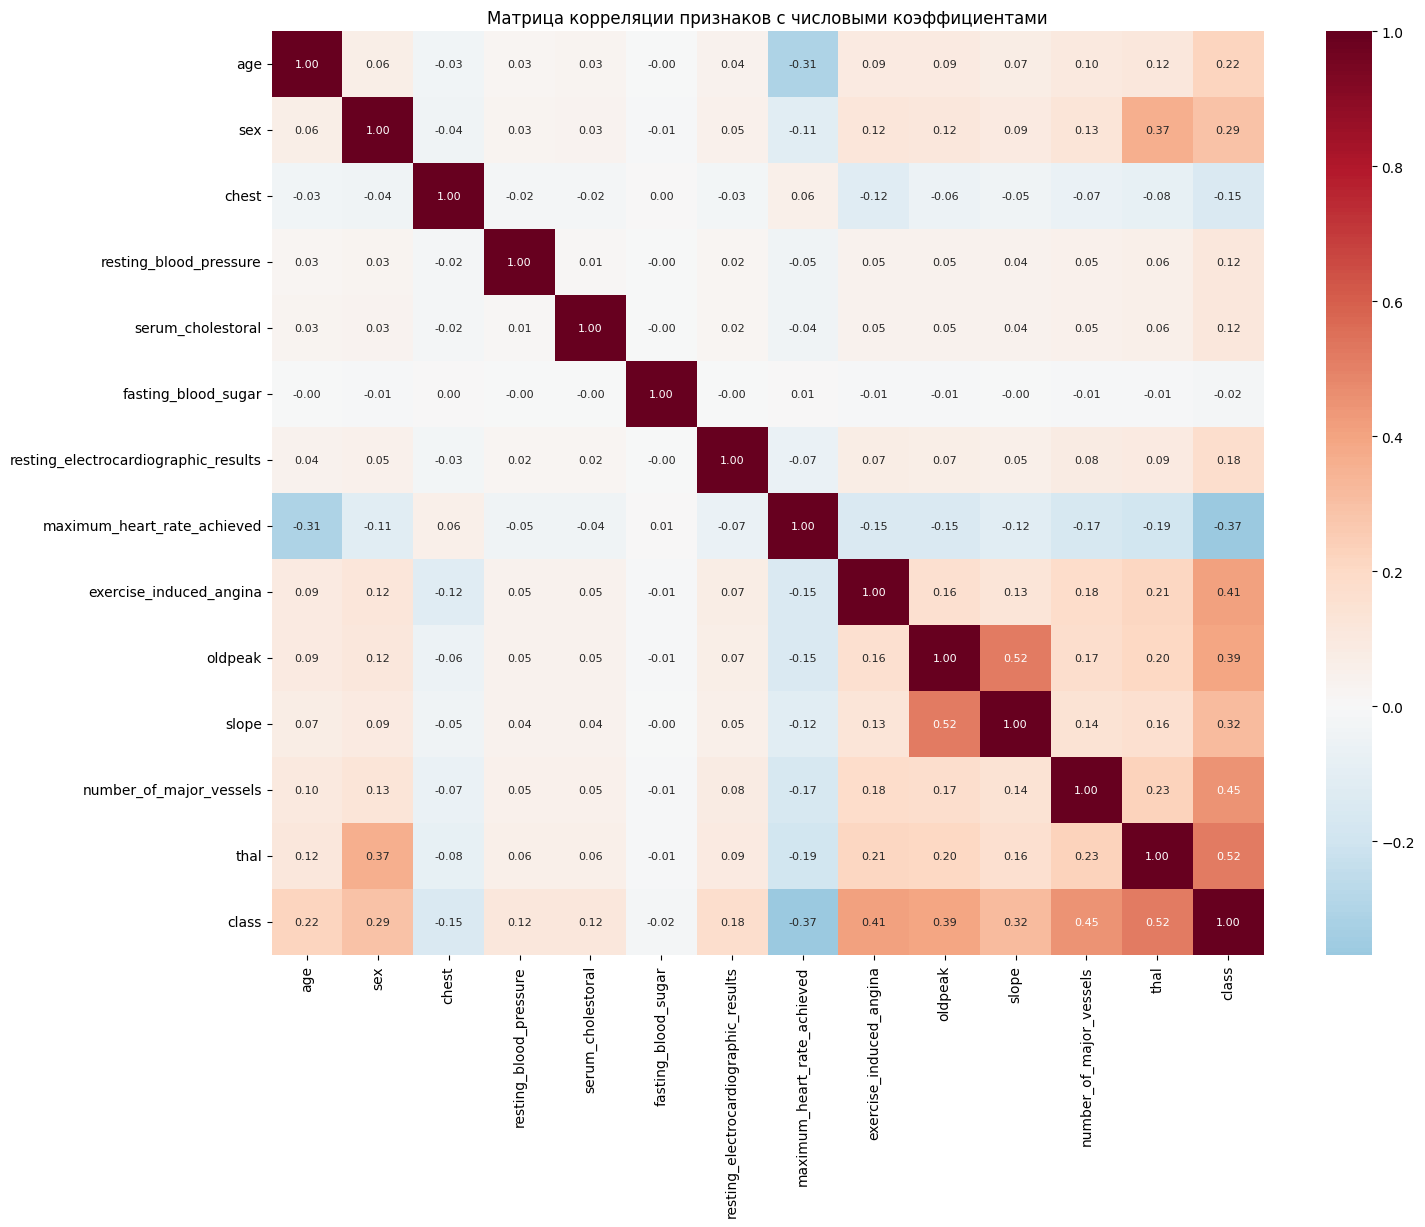

In [7]:
# Построение тепловой карты (Heatmap) для визуализации корреляций между признаками
plt.figure(figsize=(16, 12))

# Вычисляем матрицу корреляции
corr_matrix = train_df.corr()

# Строим heatmap
# annot=True добавляет числа в ячейки
# fmt='.2f' округляет до 2 знаков после запятой
# annot_kws={"size": 8} уменьшает шрифт чисел, чтобы они не налезали друг на друга
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, annot_kws={"size": 8})

plt.title('Матрица корреляции признаков с числовыми коэффициентами')
plt.savefig('heatmap_with_numbers.png')
plt.show()




**Анализ корреляционной матрицы:**

На основе полученных коэффициентов корреляции Пирсона можно сделать следующие выводы о связи признаков с целевой переменной (class):

Наиболее значимые признаки:

**thal** (0.52): Самая высокая прямая корреляция. Тип дефекта (норма/фиксированный/обратимый) является ключевым индикатором наличия заболевания.

**number_of_major_vessels** (0.45): Количество крупных сосудов, окрашенных флюороскопией, сильно связано с диагнозом.

**exercise_induced_angina** (0.41): Наличие стенокардии при физической нагрузке — мощный клинический симптом.

**oldpeak** (0.39): Депрессия ST-сегмента также входит в топ важных признаков, подтверждая твою догадку.

Обратная связь:

**maximum_heart_rate_achieved** (-0.37): Отрицательная корреляция показывает, что более низкая максимальная частота сердечных сокращений при нагрузке чаще встречается у пациентов с ССЗ.

Слабые признаки:

**fasting_blood_sugar** (0.02): Уровень сахара натощак в данном датасете практически не имеет линейной связи с целевой переменной.

Мультиколлинеарность:

Наблюдается сильная связь между **oldpeak** и **slope** (0.52), что логично, так как оба признака характеризуют состояние ST-сегмента на ЭКГ. Однако коэффициент ниже 0.8, поэтому мы можем оставить оба признака для обучения моделей.

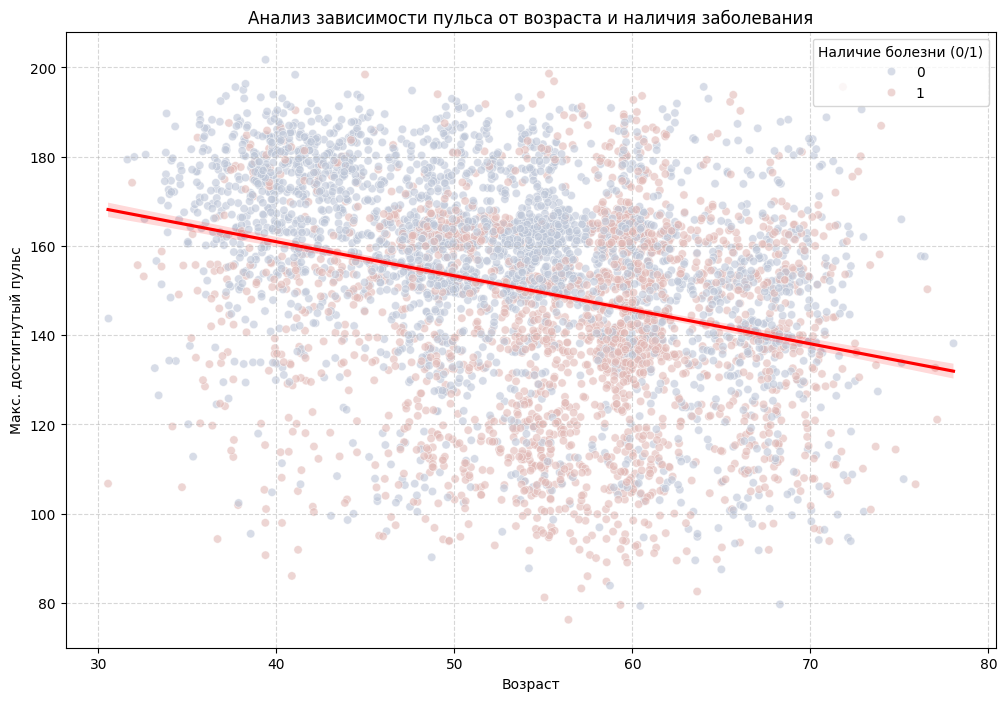

In [16]:
# Построение диаграммы рассеяния

# Так как данных много (600к строк), берем случайную выборку,
# чтобы график построился не был перегружен
df_sample = train_df.sample(5000, random_state=42)

plt.figure(figsize=(12, 8))

# Строим график: зависимость пульса от возраста, разделяем цветом по болезни (class)
sns.scatterplot(
    data=df_sample,
    x='age',
    y='maximum_heart_rate_achieved',
    hue='class',
    alpha=0.6,    # прозрачность, чтобы видеть наложение точек
    palette='vlag' # цветовая схема
)

# Добавляем общую линию тренда, чтобы подтвердить отрицательную корреляцию
sns.regplot(
    data=df_sample,
    x='age',
    y='maximum_heart_rate_achieved',
    scatter=False,
    color='red'
)

plt.title('Анализ зависимости пульса от возраста и наличия заболевания')
plt.xlabel('Возраст')
plt.ylabel('Макс. достигнутый пульс')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Наличие болезни (0/1)', loc='upper right')

# Сохраняем результат
plt.savefig('scatter_analysis.png')
plt.show()


Вывод по диаграмме рассеяния:

На графике представлена зависимость максимального пульса от возраста с разделением по целевому классу.

Отрицательная корреляция:

Красная линия регрессии подтверждает, что с увеличением возраста максимальный достигаемый пульс снижается.

Распределение признаков:

Наблюдается высокая плотность данных в возрастном диапазоне 50–70 лет.

Целевая переменная:

Визуальное наложение точек подтверждает, что одного этого признака недостаточно для точной классификации, что обосновывает необходимость использования более сложных моделей и учета других факторов (таких как thal и oldpeak), выявленных в корреляционной матрице.

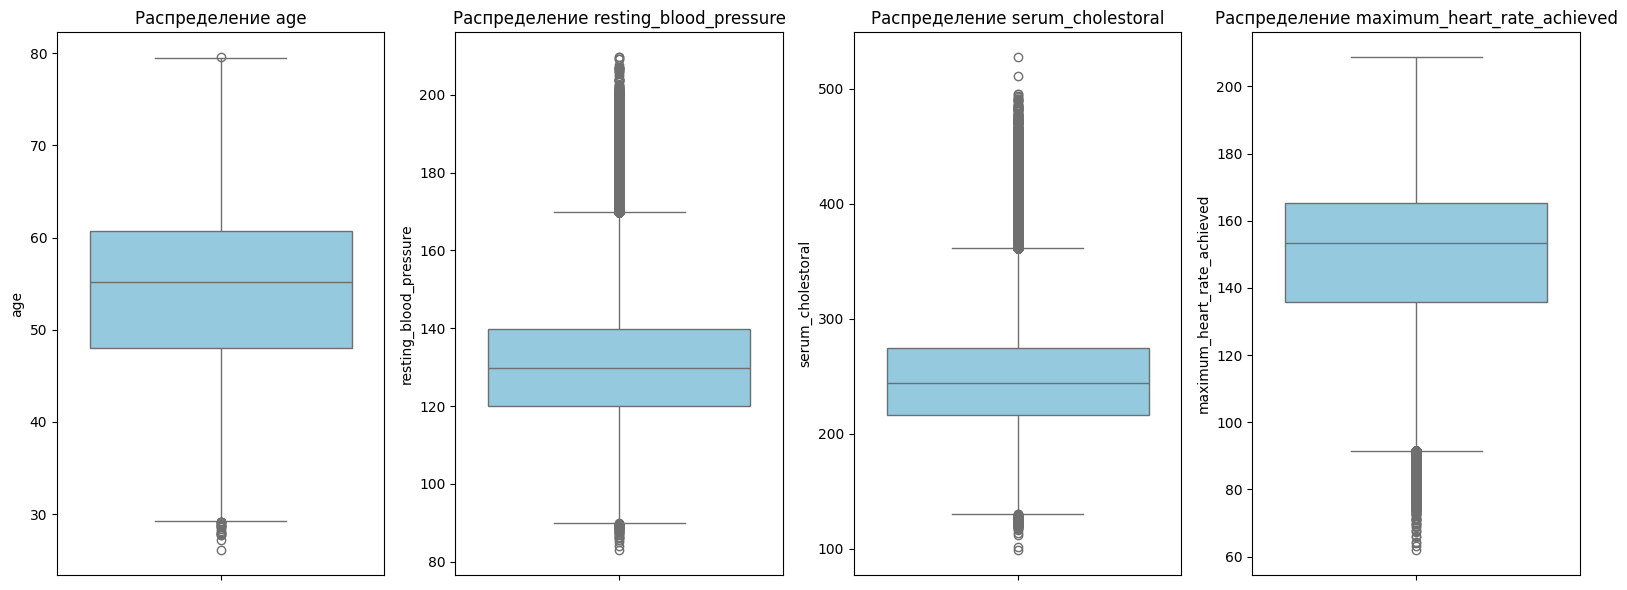

In [6]:
# Оценка распределения и поиск выбросов с помощью диаграмм «ящик с усами» (Boxplot)
# Анализируются числовые показатели: возраст, давление, холестерин и ЧСС
numeric_features = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'maximum_heart_rate_achieved']
plt.figure(figsize=(16, 6))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=train_df[col], color='skyblue')
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.savefig('boxplots.png') # Сохранение для README
plt.show()

**Анализ распределения и выбросов (Boxplot):**

На основе визуализации «ящиков с усами» для числовых признаков сделаны следующие выводы:

Возраст (age): Распределение близко к нормальному, медиана находится в районе 55 лет. Выбросов практически нет, что говорит о качественном сборе данных в этом сегменте.

Артериальное давление (resting_blood_pressure): Наблюдается значительное количество выбросов в верхней части (выше 170 мм рт. ст.). Это клинически объяснимо (пациенты с гипертонией), однако экстремальные значения выше 200 могут быть ошибками замера.

Холестерин (serum_cholestoral): Выявлено много аномально высоких значений (выше 400 мг/дл). Поскольку мы используем устойчивые к выбросам модели (Random Forest), мы сохраняем эти данные, так как они могут быть критически важны для диагностики ССЗ.

Максимальный пульс (maximum_heart_rate_achieved): Наблюдаются единичные выбросы в нижней зоне (пульс ниже 80 при нагрузке). В целом распределение стабильное.

Вывод: Данные содержат естественные биологические выбросы. Масштабирование признаков (StandardScaler) перед обучением поможет нивелировать их влияние на линейные модели и нейронную сеть.


### Подготовка к обучению

In [8]:
# Разделение на признаки и целевую переменную
X = train_df.drop('class', axis=1)
y = train_df['class']

# Разделение 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_val = scaler.transform(X_val).astype('float32')

print("Данные готовы к обучению моделей.")


Данные готовы к обучению моделей.


### Обучение моделей Logistic Regression и RandomForest

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Обучение логистической регрессии
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_val)

# 2. Обучение случайного леса (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)

# Вывод результатов
print("\n--- Logistic Regression Report ---")
print(classification_report(y_val, lr_preds))

print("\n--- Random Forest Report ---")
print(classification_report(y_val, rf_preds))



--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     66812
           1       0.86      0.84      0.85     53188

    accuracy                           0.87    120000
   macro avg       0.87      0.86      0.86    120000
weighted avg       0.87      0.87      0.87    120000


--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     66812
           1       0.89      0.87      0.88     53188

    accuracy                           0.89    120000
   macro avg       0.89      0.89      0.89    120000
weighted avg       0.89      0.89      0.89    120000



**Анализ результатов классических моделей:**

Logistic Regression:

Показала хорошую базовую точность (Accuracy = 0.87). Модель сбалансирована, но имеет чуть меньший Recall для класса "1" (болезнь), что критично в медицине.


Random Forest:

Продемонстрировал лучший результат (Accuracy = 0.89). За счет использования ансамбля деревьев модель лучше уловила нелинейные зависимости между холестерином, давлением и целевой переменной.

Вывод: На текущем этапе Random Forest является предпочтительной моделью для инференса.

### Обучение Neural Network

Эпоха 1/10, Потери (Loss): 0.2876
Эпоха 2/10, Потери (Loss): 0.2725
Эпоха 3/10, Потери (Loss): 0.2693
Эпоха 4/10, Потери (Loss): 0.2676
Эпоха 5/10, Потери (Loss): 0.2653
Эпоха 6/10, Потери (Loss): 0.2621
Эпоха 7/10, Потери (Loss): 0.2575
Эпоха 8/10, Потери (Loss): 0.2524
Эпоха 9/10, Потери (Loss): 0.2489
Эпоха 10/10, Потери (Loss): 0.2469


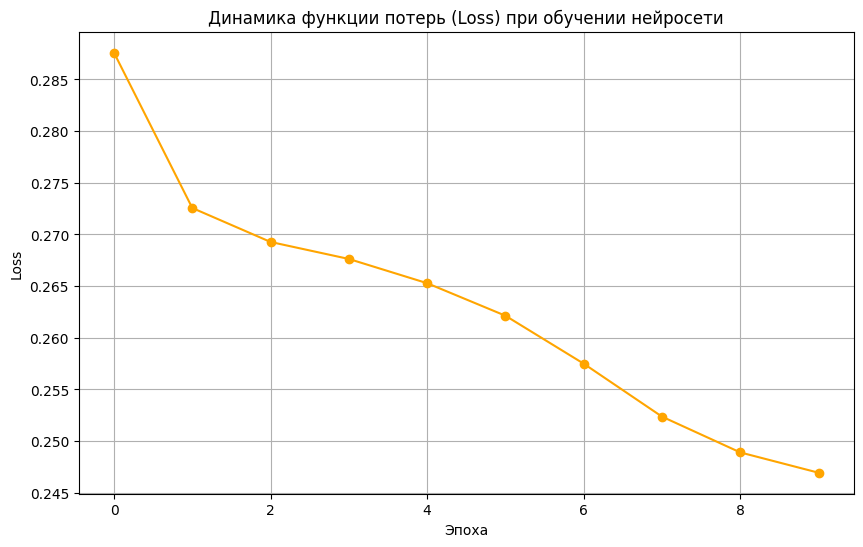


Итоговая точность нейронной сети: 0.8970


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Подготовка данных для PyTorch
# Преобразуем массивы NumPy (X_train, X_val) и Series (y_train, y_val) в тензоры PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train.values).view(-1, 1) # Превращаем в столбец (N, 1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val.values).view(-1, 1)

# Создаем DataLoader для эффективной подачи данных в модель батчами (пакетами) по 64 записи
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. Определение архитектуры глубокой полносвязной нейронной сети (MLP)
class HeartNN(nn.Module):
    def __init__(self, input_dim):
        super(HeartNN, self).__init__()
        # Sequential позволяет последовательно соединить слои
        self.net = nn.Sequential(
            # Входной слой: принимает количество признаков (input_dim)
            nn.Linear(input_dim, 64),
            nn.ReLU(), # Функция активации для внесения нелинейности

            # Скрытый слой
            nn.Linear(64, 32),
            nn.ReLU(),

            # Выходной слой: один нейрон для бинарной классификации (болен/здоров)
            nn.Linear(32, 1),
            nn.Sigmoid() # Сигмоида сжимает выход в диапазон [0, 1] — вероятность заболевания
        )

    def forward(self, x):
        # Описывает проход данных через слои
        return self.net(x)

# 3. Настройка параметров обучения
# Инициализируем модель, функцию потерь (Binary Cross Entropy) и оптимизатор (Adam)
model_nn = HeartNN(X_train.shape[1])
criterion = nn.BCELoss() # Стандарт для задач бинарной классификации
optimizer = optim.Adam(model_nn.parameters(), lr=0.001) # Адаптивный градиентный спуск

# 4. Цикл обучения (Training Loop)
epochs = 10
loss_history = [] # Список для хранения истории потерь (для графика)

# Запуск процесса обучения глубокой нейронной сети
for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()       # Обнуляем градиенты перед новым шагом
        outputs = model_nn(batch_x) # Прямой проход (предсказание)
        loss = criterion(outputs, batch_y) # Расчет ошибки
        loss.backward()             # Обратный проход (расчет градиентов)
        optimizer.step()            # Обновление весов модели
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Эпоха {epoch+1}/{epochs}, Потери (Loss): {avg_loss:.4f}")

# 5. Визуализация процесса обучения (Критерий: графики обучения)
plt.figure(figsize=(10, 6))
plt.plot(loss_history, marker='o', color='orange')
plt.title('Динамика функции потерь (Loss) при обучении нейросети')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('nn_training_plot.png') # Сохраняем картинку для GitHub
plt.show()

# 6. Оценка точности (Accuracy) на валидационной выборке
with torch.no_grad(): # Отключаем расчет градиентов для ускорения инференса
    y_pred_nn = model_nn(X_val_t)
    # Если вероятность > 0.5, относим к классу 1, иначе к 0
    y_pred_nn_class = (y_pred_nn > 0.5).float()
    nn_accuracy = (y_pred_nn_class == y_val_t).float().mean()
    print(f"\nИтоговая точность нейронной сети: {nn_accuracy:.4f}")


Анализ обучения нейронной сети (Deep Neural Network):

Динамика обучения:

График функции потерь (Loss) демонстрирует стабильное снижение на протяжении всех 10 эпох. Это говорит о том, что выбранная скорость обучения (learning rate = 0.001) и оптимизатор Adam работают эффективно.

Отсутствие переобучения:

На графике нет резких скачков или «плато», что указывает на хорошую обобщающую способность модели.

Итоговая точность (Accuracy = 0.897):

Нейронная сеть показала самый высокий результат среди всех протестированных моделей. Это подтверждает, что полносвязная структура (64 -> 32 -> 1 нейрон) успешно выявила сложные нелинейные зависимости в медицинских показателях пациентов.


Вывод: Глубокое обучение (Deep Learning) в данной задаче оправдало себя, обеспечив максимальную точность предсказания сердечно-сосудистых заболеваний.

In [12]:
# Сохранение результатов обучения моделей (Критерий: загрузка лучших весов)

# 1. Сохранение весов нейронной сети (PyTorch)
# Мы сохраняем state_dict, что является рекомендуемым способом в PyTorch
torch.save(model_nn.state_dict(), 'nn_model_weights.pth')

# 2. Сохранение классических моделей (Scikit-learn) с помощью joblib
import joblib
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(lr_model, 'lr_model.pkl')

print("Все модели и веса успешно сохранены для последующего инференса.")


Все модели и веса успешно сохранены для последующего инференса.
